Import packages

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle
import os
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

Set a random seed for Numpy and Tensor Flow

In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

Load in data

In [4]:
images = np.load('images.npy')
labels = pd.read_csv('labels.csv')

In [5]:
labels.value_counts()

Label                    
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Charlock                     390
Sugar beet                   385
Cleavers                     287
Black-grass                  263
Shepherds Purse              231
Maize                        221
Common wheat                 221
Name: count, dtype: int64

Visualizations

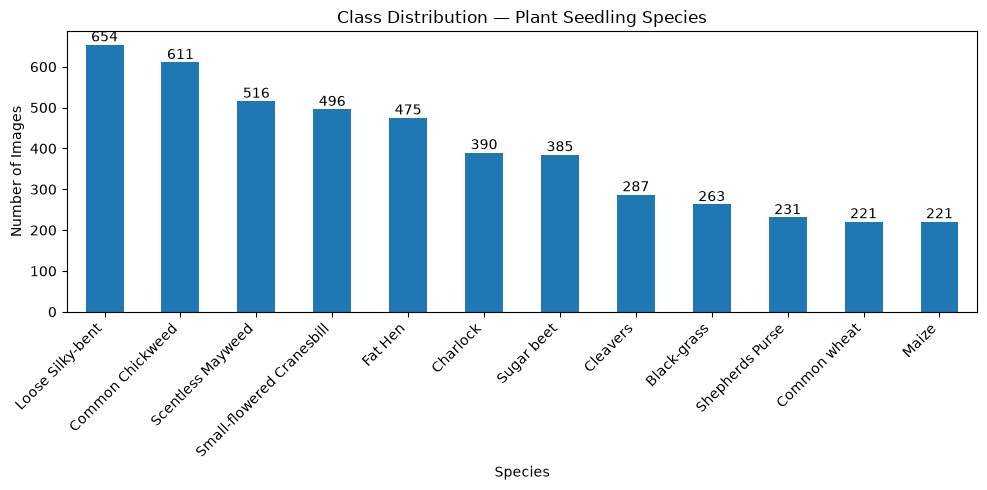

In [6]:
counts = labels.iloc[:, 0].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
counts.plot(kind="bar", ax=ax)
ax.bar_label(ax.containers[0])
ax.set_title("Class Distribution — Plant Seedling Species")
ax.set_xlabel("Species")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
print('---Dataset Attributes---')
print(f'Shape: {images.shape} \nData type: {images.dtype}')
print()
print('---Total Color Attributes---')
print(f'Min: {images.min()}\nMax: {images.max()}\nMean: {images.mean()}\nStdDev: {images.std()}')
print()
print('---Individual Color Attributes---')
print(f'Mean (rgb): {images.mean(axis=(0, 1, 2))}')
print(f'StdDev (rgb): {images.std(axis=(0, 1, 2))}')

---Dataset Attributes---
Shape: (4750, 128, 128, 3) 
Data type: uint8

---Total Color Attributes---
Min: 0
Max: 255
Mean: 70.04363745545504
StdDev: 31.996876308514896

---Individual Color Attributes---
Mean (rgb): [52.74117098 73.66265106 83.72709033]
StdDev (rgb): [32.55663286 28.19947915 26.76837361]


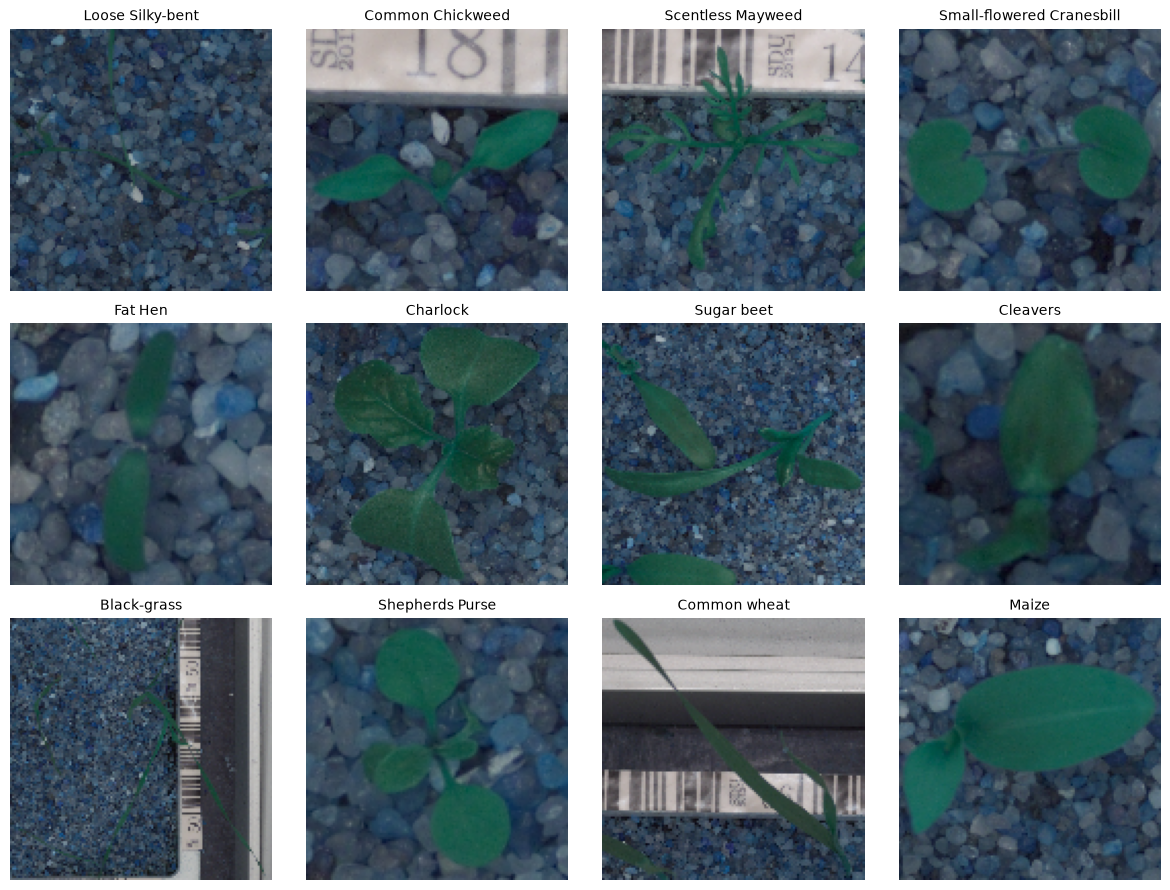

In [8]:
y_raw = labels.iloc[:, 0]
classes = counts.index

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, cls in zip(axes.flat, classes):
    idx = np.where(y_raw == cls)[0][0]
    ax.imshow(images[idx])
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
print(f"This dataset contains {len(labels)} images across {y_raw.nunique()} classes.")

This dataset contains 4750 images across 12 classes.


Encode labels

In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
class_names = le.classes_

print(y_encoded[:10])
print(class_names)
print(f'{len(class_names)} classes \ny shape: {y_encoded.shape}')

[10 10 10 10 10 10 10 10 10 10]
['Black-grass' 'Charlock' 'Cleavers' 'Common Chickweed' 'Common wheat'
 'Fat Hen' 'Loose Silky-bent' 'Maize' 'Scentless Mayweed'
 'Shepherds Purse' 'Small-flowered Cranesbill' 'Sugar beet']
12 classes 
y shape: (4750,)


Split training, validation, and testing data

In [11]:
X_temp, X_test, y_temp, y_test = train_test_split(images, y_encoded, test_size=0.15, stratify=y_encoded, random_state=SEED)

val_size = 0.15 / 0.85
print(f'Validation share of temp: {val_size}')
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size, stratify=y_temp, random_state=SEED)

for name, XX, yy in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    print(f'{name}: X {XX.shape}, y {yy.shape}')

assert len(X_train) + len(X_val) + len(X_test) == len(images) and len(X_test) == len(y_test)

Validation share of temp: 0.17647058823529413
train: X (3324, 128, 128, 3), y (3324,)
val: X (713, 128, 128, 3), y (713,)
test: X (713, 128, 128, 3), y (713,)


In [12]:
IMG_SIZE = 64

def resize_uint8(arr):
    return tf.image.resize(arr, (IMG_SIZE, IMG_SIZE)).numpy().astype("uint8")

X_train_r = resize_uint8(X_train)
X_val_r   = resize_uint8(X_val)
X_test_r  = resize_uint8(X_test)

print(X_train_r.shape, X_val_r.shape, X_test_r.shape, X_train_r.dtype)

processed = {
    "X_train": X_train_r, "y_train": y_train,
    "X_val":   X_val_r,   "y_val":   y_val,
    "X_test":  X_test_r,  "y_test":  y_test,
    "class_names": class_names,
    "img_size": IMG_SIZE,
}

with open("processed_data.pkl", "wb") as f:
    pickle.dump(processed, f)

(3324, 64, 64, 3) (713, 64, 64, 3) (713, 64, 64, 3) uint8


In [13]:
with open('processed_data.pkl', 'rb') as f:
    processed = pickle.load(f)

X_train_r = processed['X_train']; y_train = processed['y_train']
X_val_r = processed['X_val']; y_val = processed['y_val']
X_test_r = processed['X_test']; y_test = processed['y_test']
class_names = processed['class_names']
print(os.path.getsize('processed_data.pkl') / 1e6, 'MB')

58.406742 MB


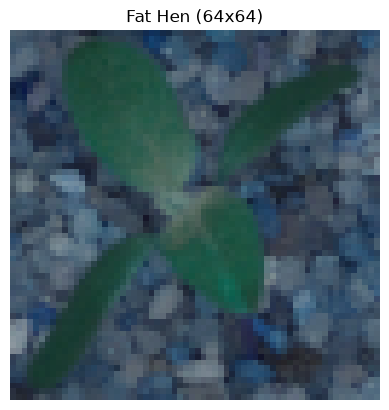

In [21]:
plt.imshow(X_train_r[0])
plt.title(f'{class_names[y_train[0]]} ({IMG_SIZE}x{IMG_SIZE})')
plt.axis('off')
plt.show()

Create convolutional neural network

In [22]:
model = models.Sequential([
    layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3]),
    layers.Rescaling(1.0/255),

    layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    layers.RandomRotation(0.2, seed=SEED),
    layers.RandomZoom(0.2, seed=SEED),

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5, seed=SEED),
    layers.Dense(len(class_names), activation='softmax'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,500 (4.36 MB)

 Trainable params: 1,143,500 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Model training

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_r, y_train,
    validation_data=(X_val_r, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.1297 - loss: 2.4508 - val_accuracy: 0.1374 - val_loss: 2.4285
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.2650 - loss: 2.1980 - val_accuracy: 0.3450 - val_loss: 1.8293
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.3544 - loss: 1.8643 - val_accuracy: 0.4362 - val_loss: 1.6936
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.4170 - loss: 1.6895 - val_accuracy: 0.4853 - val_loss: 1.5209
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.4892 - loss: 1.4857 - val_accuracy: 0.6003 - val_loss: 1.2025
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.5412 - loss: 1.3470 - val_accuracy: 0.6508 - val_loss: 1.0822
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.5463 - loss: 1.2942 - val_accuracy: 0.6662 - val_loss: 1.0267
Epoch 8/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.5767 - loss: 1.2268 - 

In [27]:
model.save('seedling_cnn.keras')

loaded_model = tf.keras.models.load_model("seedling_cnn.keras")
print(loaded_model.evaluate(X_test_r, y_test))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8513 - loss: 0.4690
[0.46896716952323914, 0.851332426071167]


Training graph

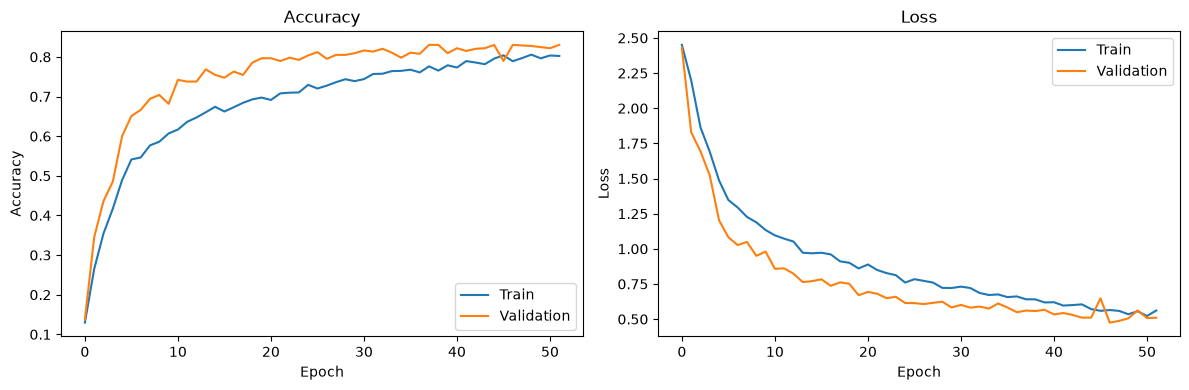

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

Test accuracy: 0.8513
Test loss: 0.4690
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
                           precision    recall  f1-score   support

              Black-grass       0.55      0.28      0.37        40
                 Charlock       0.86      0.92      0.89        59
                 Cleavers       0.80      0.74      0.77        43
         Common Chickweed       0.95      0.97      0.96        92
             Common wheat       0.84      0.82      0.83        33
                  Fat Hen       0.91      0.90      0.91        71
         Loose Silky-bent       0.77      0.88      0.82        98
                    Maize       0.86      0.91      0.88        33
        Scentless Mayweed       0.77      0.90      0.83        77
          Shepherds Purse       0.90      0.74      0.81        35
Small-flowered Cranesbill       0.94      0.88      0.91        74
               Sugar beet       0.92      0.93      0.92        58

                 accuracy                      

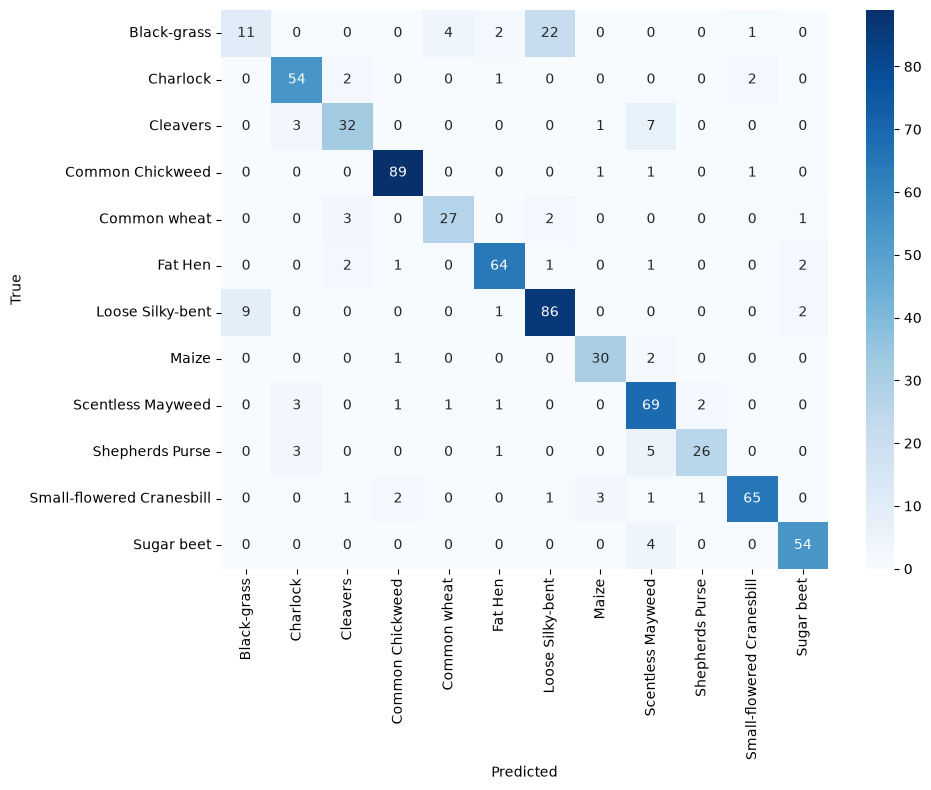

In [30]:
loaded_model = tf.keras.models.load_model('seedling_cnn.keras')

test_loss, test_acc = loaded_model.evaluate(X_test_r, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}\nTest loss: {test_loss:.4f}')

y_pred = loaded_model.predict(X_test_r).argmax(axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [ ]:
best = np.argmin(history.history['val_loss'])

print(f'Best epoch: {best + 1} of {len(history.history['loss'])} run')
print(f'Training accuracy:   {history.history['accuracy'][best]:.4f}')
print(f'Training loss:       {history.history['loss'][best]:.4f}')
print(f'Validation accuracy: {history.history['val_accuracy'][best]:.4f}')
print(f'Validation loss:     {history.history['val_loss'][best]:.4f}')

Best epoch: 47 of 52 run
Training accuracy:   0.7891
Training loss:       0.5647
Validation accuracy: 0.8303
Validation loss:     0.4753


In [ ]:

print